# Phase 6: Final Validation & Comprehensive Report

## Objectif
Synthétiser tous les résultats des phases 1-5, générer des visualisations, valider l'intégrité du dataset VLM, et produire un rapport final complet.

## Phases Complétées
- **Phase 1**: Dataset Integration (30,513 images)
- **Phase 2**: Adaptive Thresholds & Fallback System
- **Phase 3**: Batch Validation (1,000 images, 100% succès)
- **Phase 4**: Production Processing (30,491/30,513 = 99.9% succès)
- **Phase 5**: VLM Dataset Preparation (80/10/10 splits, Qwen2.5-VL format)

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

# Configuration matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✓ Imports loaded")

✓ Imports loaded


## 2. Configuration & Paths

In [2]:
# Paths
BASE_DIR = Path("/home/hounfodjidagba/learning/cassava")
OUTPUTS_DIR = BASE_DIR / "outputs"
VLM_DATASET_DIR = OUTPUTS_DIR / "vlm_dataset"
PROCESSED_DIR = OUTPUTS_DIR / "processed"
VIZ_DIR = OUTPUTS_DIR / "visualizations"

# Create visualization directory
VIZ_DIR.mkdir(parents=True, exist_ok=True)

# Disease mapping
DISEASE_MAPPING = {
    0: 'Cassava Bacterial Blight (CBB)',
    1: 'Cassava Brown Streak Disease (CBSD)',
    2: 'Cassava Green Mottle (CGM)',
    3: 'Cassava Mosaic Disease (CMD)',
    4: 'Healthy'
}

print(f"Base directory: {BASE_DIR}")
print(f"Outputs directory: {OUTPUTS_DIR}")
print(f"Visualizations will be saved to: {VIZ_DIR}")
print("\n✓ Configuration loaded")

Base directory: /home/hounfodjidagba/learning/cassava
Outputs directory: /home/hounfodjidagba/learning/cassava/outputs
Visualizations will be saved to: /home/hounfodjidagba/learning/cassava/outputs/visualizations

✓ Configuration loaded


## 3. Load All Results

In [3]:
# Load production processing summary
production_summary_path = PROCESSED_DIR / "production_summary.json"
with open(production_summary_path, 'r') as f:
    production_summary = json.load(f)

# Load VLM dataset info
dataset_info_path = VLM_DATASET_DIR / "dataset_info.json"
with open(dataset_info_path, 'r') as f:
    dataset_info = json.load(f)

# Load JSONL files
train_data = []
with open(VLM_DATASET_DIR / "train.jsonl", 'r') as f:
    for line in f:
        train_data.append(json.loads(line))

val_data = []
with open(VLM_DATASET_DIR / "val.jsonl", 'r') as f:
    for line in f:
        val_data.append(json.loads(line))

test_data = []
with open(VLM_DATASET_DIR / "test.jsonl", 'r') as f:
    for line in f:
        test_data.append(json.loads(line))

print("Loaded data:")
print(f"  Production summary: {len(production_summary.get('by_class', {}))} classes")
print(f"  Dataset info: {dataset_info['total_images']} total images")
print(f"  Train JSONL: {len(train_data)} entries")
print(f"  Val JSONL: {len(val_data)} entries")
print(f"  Test JSONL: {len(test_data)} entries")
print("\n✓ All results loaded successfully")

Loaded data:
  Production summary: 5 classes
  Dataset info: 30491 total images
  Train JSONL: 24392 entries
  Val JSONL: 3049 entries
  Test JSONL: 3050 entries

✓ All results loaded successfully


## 4. Overall Pipeline Statistics

In [4]:
# Extract overall stats from production summary
total_images = production_summary['total_images']
total_success = production_summary['successful']
total_failed = production_summary['failed']
total_time_hours = production_summary['processing_time_hours']

# Calculate primary vs fallback
primary_count = production_summary['primary']
fallback_count = production_summary['fallback']

# Calculate average time per image
total_time_ms = 0
total_count = 0
for class_stats in production_summary['by_class'].values():
    total_time_ms += class_stats['avg_time_ms'] * class_stats['total']
    total_count += class_stats['total']
avg_time_ms = total_time_ms / total_count if total_count > 0 else 0

success_rate = (total_success / total_images) * 100
primary_rate = (primary_count / total_images) * 100
fallback_rate = (fallback_count / total_images) * 100
failure_rate = (total_failed / total_images) * 100

print("="*80)
print("OVERALL PIPELINE STATISTICS")
print("="*80)
print(f"\nTotal Images Processed: {total_images:,}")
print(f"Success Rate: {success_rate:.2f}% ({total_success:,} images)")
print(f"Failure Rate: {failure_rate:.2f}% ({total_failed} images)")
print(f"\nProcessing Breakdown:")
print(f"  • Primary Pipeline: {primary_rate:.1f}% ({primary_count:,} images)")
print(f"  • Fallback Pipeline: {fallback_rate:.1f}% ({fallback_count:,} images)")
print(f"  • Failed: {failure_rate:.2f}% ({total_failed} images)")
print(f"\nPerformance:")
print(f"  • Total Processing Time: {total_time_hours:.2f} hours")
print(f"  • Average Time per Image: {avg_time_ms:.0f} ms")
print(f"  • Throughput: {(total_images / (total_time_hours * 3600)):.1f} images/second")
print("="*80)

# Store for report
overall_stats = {
    'total_images': total_images,
    'total_success': total_success,
    'total_failed': total_failed,
    'success_rate': success_rate,
    'failure_rate': failure_rate,
    'primary_count': primary_count,
    'primary_rate': primary_rate,
    'fallback_count': fallback_count,
    'fallback_rate': fallback_rate,
    'total_time_hours': total_time_hours,
    'avg_time_ms': avg_time_ms
}

OVERALL PIPELINE STATISTICS

Total Images Processed: 30,513
Success Rate: 99.93% (30,491 images)
Failure Rate: 0.07% (22 images)

Processing Breakdown:
  • Primary Pipeline: 95.0% (28,995 images)
  • Fallback Pipeline: 4.9% (1,496 images)
  • Failed: 0.07% (22 images)

Performance:
  • Total Processing Time: 1.39 hours
  • Average Time per Image: 284 ms
  • Throughput: 6.1 images/second


## 5. Per-Class Breakdown

In [5]:
# Create detailed per-class DataFrame
class_breakdown = []

for class_label_str, stats in production_summary['by_class'].items():
    class_label = int(class_label_str)
    disease_name = DISEASE_MAPPING[class_label]
    
    total = stats['total']
    success = stats['successful']
    failed = stats['failed']
    primary = stats.get('primary', 0)
    fallback = stats.get('fallback', 0)
    avg_time = stats['avg_time_ms']
    
    class_breakdown.append({
        'Class': class_label,
        'Disease': disease_name,
        'Total': total,
        'Success': success,
        'Failed': failed,
        'Success Rate (%)': (success / total) * 100 if total > 0 else 0,
        'Primary': primary,
        'Fallback': fallback,
        'Primary Rate (%)': (primary / total) * 100 if total > 0 else 0,
        'Fallback Rate (%)': (fallback / total) * 100 if total > 0 else 0,
        'Avg Time (ms)': avg_time
    })

class_df = pd.DataFrame(class_breakdown)
class_df = class_df.sort_values('Class')

print("\nPER-CLASS BREAKDOWN")
print("="*120)
print(class_df.to_string(index=False))
print("="*120)

# Save to CSV
class_df.to_csv(OUTPUTS_DIR / "per_class_breakdown.csv", index=False)
print(f"\n✓ Saved to {OUTPUTS_DIR / 'per_class_breakdown.csv'}")


PER-CLASS BREAKDOWN
 Class                             Disease  Total  Success  Failed  Success Rate (%)  Primary  Fallback  Primary Rate (%)  Fallback Rate (%)  Avg Time (ms)
     0      Cassava Bacterial Blight (CBB)   1087     1087       0        100.000000     1054        33         96.964121           3.035879     253.793015
     1 Cassava Brown Streak Disease (CBSD)   5186     5186       0        100.000000     5117        69         98.669495           1.330505     273.056808
     2          Cassava Green Mottle (CGM)   2386     2386       0        100.000000     2342        44         98.155909           1.844091     255.097266
     3        Cassava Mosaic Disease (CMD)  18158    18136      22         99.878841    16905      1231         93.099460           6.779381     292.323039
     4                             Healthy   3696     3696       0        100.000000     3577       119         96.780303           3.219697     283.806190

✓ Saved to /home/hounfodjidagba/learning/c

## 6. Quality Metrics Analysis

In [6]:
print("QUALITY METRICS SUMMARY")
print("="*80)
print(f"\nPrimary Pipeline Performance:")
print(f"  Total processed by primary: {primary_count:,} images ({primary_rate:.1f}%)")
print(f"  Average processing time: {avg_time_ms:.0f} ms")
print(f"\nKey Quality Indicators:")
print(f"  • High primary pipeline usage (95%+): {'✓' if primary_rate >= 95 else '⚠'} Indicates robust initial detection")
print(f"  • Low fallback rate (<5%): {'✓' if fallback_rate < 5 else '⚠'} Adaptive thresholds working effectively")
print(f"  • Minimal failures (<1%): {'✓' if failure_rate < 1 else '⚠'} Excellent overall pipeline reliability")
print(f"\nClass-Specific Insights:")

for _, row in class_df.iterrows():
    if row['Failed'] > 0:
        print(f"  ⚠ {row['Disease']}: {row['Failed']} failures ({row['Failed']/row['Total']*100:.2f}%)")
    elif row['Fallback Rate (%)'] > 10:
        print(f"  ⚡ {row['Disease']}: High fallback rate ({row['Fallback Rate (%)']:.1f}%)")
    else:
        print(f"  ✓ {row['Disease']}: Excellent performance (primary: {row['Primary Rate (%)']:.1f}%)")

print("="*80)

QUALITY METRICS SUMMARY

Primary Pipeline Performance:
  Total processed by primary: 28,995 images (95.0%)
  Average processing time: 284 ms

Key Quality Indicators:
  • High primary pipeline usage (95%+): ✓ Indicates robust initial detection
  • Low fallback rate (<5%): ✓ Adaptive thresholds working effectively
  • Minimal failures (<1%): ✓ Excellent overall pipeline reliability

Class-Specific Insights:
  ✓ Cassava Bacterial Blight (CBB): Excellent performance (primary: 97.0%)
  ✓ Cassava Brown Streak Disease (CBSD): Excellent performance (primary: 98.7%)
  ✓ Cassava Green Mottle (CGM): Excellent performance (primary: 98.2%)
  ⚠ Cassava Mosaic Disease (CMD): 22 failures (0.12%)
  ✓ Healthy: Excellent performance (primary: 96.8%)


## 7. Fallback Analysis

In [7]:
print("FALLBACK PIPELINE ANALYSIS")
print("="*80)
print(f"\nTotal Fallback Cases: {fallback_count:,} ({fallback_rate:.1f}%)")
print(f"\nFallback Distribution by Class:")
print("-"*80)

fallback_by_class = []
for _, row in class_df.iterrows():
    if row['Fallback'] > 0:
        fallback_pct = (row['Fallback'] / fallback_count) * 100 if fallback_count > 0 else 0
        class_fallback_rate = row['Fallback Rate (%)']
        fallback_by_class.append({
            'Disease': row['Disease'],
            'Fallback Count': int(row['Fallback']),
            '% of Total Fallbacks': fallback_pct,
            'Class Fallback Rate (%)': class_fallback_rate
        })

if fallback_by_class:
    fallback_df = pd.DataFrame(fallback_by_class)
    fallback_df = fallback_df.sort_values('Fallback Count', ascending=False)
    print(fallback_df.to_string(index=False))
else:
    print("No fallback cases found!")

print("\n" + "-"*80)
print("\nKey Insights:")
print("  • Fallback triggered when primary detection fails validation")
print("  • Green semantic segmentation successfully handled edge cases")
print("  • Adaptive thresholds minimized unnecessary fallback usage")
print("="*80)

FALLBACK PIPELINE ANALYSIS

Total Fallback Cases: 1,496 (4.9%)

Fallback Distribution by Class:
--------------------------------------------------------------------------------
                            Disease  Fallback Count  % of Total Fallbacks  Class Fallback Rate (%)
       Cassava Mosaic Disease (CMD)            1231             82.286096                 6.779381
                            Healthy             119              7.954545                 3.219697
Cassava Brown Streak Disease (CBSD)              69              4.612299                 1.330505
         Cassava Green Mottle (CGM)              44              2.941176                 1.844091
     Cassava Bacterial Blight (CBB)              33              2.205882                 3.035879

--------------------------------------------------------------------------------

Key Insights:
  • Fallback triggered when primary detection fails validation
  • Green semantic segmentation successfully handled edge cases
  • A

## 8. VLM Dataset Integrity Checks

In [8]:
print("VLM DATASET INTEGRITY VALIDATION")
print("="*80)

# Check JSONL file validity
splits = {
    'train': train_data,
    'val': val_data,
    'test': test_data
}

integrity_report = {}

for split_name, data in splits.items():
    print(f"\n{split_name.upper()} Split:")
    print("-"*40)
    
    # Count entries
    entry_count = len(data)
    print(f"  Total entries: {entry_count:,}")
    
    # Validate structure
    valid_entries = 0
    invalid_entries = []
    
    for i, entry in enumerate(data):
        try:
            assert 'id' in entry, "Missing 'id' field"
            assert 'image' in entry, "Missing 'image' field"
            assert 'conversations' in entry, "Missing 'conversations' field"
            assert len(entry['conversations']) == 2, "Invalid conversation length"
            assert entry['conversations'][0]['from'] == 'human', "Invalid conversation format"
            assert entry['conversations'][1]['from'] == 'gpt', "Invalid conversation format"
            assert '<image>' in entry['conversations'][0]['value'], "Missing <image> token"
            valid_entries += 1
        except AssertionError as e:
            invalid_entries.append((i, str(e)))
    
    print(f"  Valid entries: {valid_entries:,} ({(valid_entries/entry_count)*100:.2f}%)")
    
    if invalid_entries:
        print(f"  ⚠ Invalid entries: {len(invalid_entries)}")
        for idx, error in invalid_entries[:5]:  # Show first 5
            print(f"    - Entry {idx}: {error}")
    else:
        print(f"  ✓ All entries valid")
    
    # Check image references
    image_paths = [entry['image'] for entry in data]
    print(f"  Unique image paths: {len(set(image_paths)):,}")
    
    # Sample verification
    sample_size = min(100, len(data))
    sample_indices = np.random.choice(len(data), sample_size, replace=False)
    existing_count = 0
    
    for idx in sample_indices:
        image_rel_path = data[idx]['image']
        image_full_path = VLM_DATASET_DIR / image_rel_path
        if image_full_path.exists():
            existing_count += 1
    
    print(f"  Sample file check ({sample_size} random): {existing_count}/{sample_size} exist ({(existing_count/sample_size)*100:.0f}%)")
    
    integrity_report[split_name] = {
        'total_entries': entry_count,
        'valid_entries': valid_entries,
        'invalid_entries': len(invalid_entries),
        'sample_files_exist': existing_count,
        'sample_size': sample_size
    }

print("\n" + "="*80)
print("✓ Dataset integrity validation complete")

VLM DATASET INTEGRITY VALIDATION

TRAIN Split:
----------------------------------------
  Total entries: 24,392
  Valid entries: 24,392 (100.00%)
  ✓ All entries valid
  Unique image paths: 24,392
  Sample file check (100 random): 100/100 exist (100%)

VAL Split:
----------------------------------------
  Total entries: 3,049
  Valid entries: 3,049 (100.00%)
  ✓ All entries valid
  Unique image paths: 3,049
  Sample file check (100 random): 100/100 exist (100%)

TEST Split:
----------------------------------------
  Total entries: 3,050
  Valid entries: 3,050 (100.00%)
  ✓ All entries valid
  Unique image paths: 3,050
  Sample file check (100 random): 100/100 exist (100%)

✓ Dataset integrity validation complete


## 9. Split Stratification Verification

In [9]:
print("SPLIT STRATIFICATION VERIFICATION")
print("="*80)

# Extract class distribution from metadata
def get_class_distribution(data):
    class_counts = Counter()
    for entry in data:
        class_label = entry['metadata']['label']
        class_counts[class_label] += 1
    return class_counts

train_dist = get_class_distribution(train_data)
val_dist = get_class_distribution(val_data)
test_dist = get_class_distribution(test_data)

# Create distribution DataFrame
split_distribution = []
for class_label in range(5):
    disease = DISEASE_MAPPING[class_label]
    train_count = train_dist.get(class_label, 0)
    val_count = val_dist.get(class_label, 0)
    test_count = test_dist.get(class_label, 0)
    total = train_count + val_count + test_count
    
    split_distribution.append({
        'Class': class_label,
        'Disease': disease,
        'Train': train_count,
        'Train %': (train_count / total * 100) if total > 0 else 0,
        'Val': val_count,
        'Val %': (val_count / total * 100) if total > 0 else 0,
        'Test': test_count,
        'Test %': (test_count / total * 100) if total > 0 else 0,
        'Total': total
    })

split_df = pd.DataFrame(split_distribution)

print("\nClass Distribution Across Splits:")
print("-"*120)
print(split_df.to_string(index=False))
print("-"*120)

# Verify 80/10/10 ratio
total_samples = sum(len(d) for d in splits.values())
train_ratio = (len(train_data) / total_samples) * 100
val_ratio = (len(val_data) / total_samples) * 100
test_ratio = (len(test_data) / total_samples) * 100

print(f"\nOverall Split Ratios:")
print(f"  Train: {len(train_data):,} ({train_ratio:.1f}%) - Target: 80%")
print(f"  Val:   {len(val_data):,} ({val_ratio:.1f}%) - Target: 10%")
print(f"  Test:  {len(test_data):,} ({test_ratio:.1f}%) - Target: 10%")
print(f"  Total: {total_samples:,}")

# Check if ratios are within acceptable range
if abs(train_ratio - 80) <= 1 and abs(val_ratio - 10) <= 1 and abs(test_ratio - 10) <= 1:
    print("\n✓ Split ratios are within target range (±1%)")
else:
    print("\n⚠ Split ratios deviate from target")

print("="*80)

SPLIT STRATIFICATION VERIFICATION

Class Distribution Across Splits:
------------------------------------------------------------------------------------------------------------------------
 Class                             Disease  Train   Train %  Val     Val %  Test    Test %  Total
     0      Cassava Bacterial Blight (CBB)    869 79.944802  109 10.027599   109 10.027599   1087
     1 Cassava Brown Streak Disease (CBSD)   4149 80.003857  518  9.988430   519 10.007713   5186
     2          Cassava Green Mottle (CGM)   1909 80.008382  239 10.016764   238  9.974853   2386
     3        Cassava Mosaic Disease (CMD)  14508 79.995589 1814 10.002206  1814 10.002206  18136
     4                             Healthy   2957 80.005411  369  9.983766   370 10.010823   3696
------------------------------------------------------------------------------------------------------------------------

Overall Split Ratios:
  Train: 24,392 (80.0%) - Target: 80%
  Val:   3,049 (10.0%) - Target: 10%
  T

## 10. Dataset Statistics Summary

In [10]:
import os

print("VLM DATASET STATISTICS SUMMARY")
print("="*80)

# File sizes
train_size = os.path.getsize(VLM_DATASET_DIR / "train.jsonl") / (1024 * 1024)  # MB
val_size = os.path.getsize(VLM_DATASET_DIR / "val.jsonl") / (1024 * 1024)
test_size = os.path.getsize(VLM_DATASET_DIR / "test.jsonl") / (1024 * 1024)
total_jsonl_size = train_size + val_size + test_size

print(f"\nJSONL File Sizes:")
print(f"  train.jsonl: {train_size:.2f} MB ({len(train_data):,} entries)")
print(f"  val.jsonl:   {val_size:.2f} MB ({len(val_data):,} entries)")
print(f"  test.jsonl:  {test_size:.2f} MB ({len(test_data):,} entries)")
print(f"  Total:       {total_jsonl_size:.2f} MB")

# Class distribution
print(f"\nClass Distribution (Total Dataset):")
total_class_dist = Counter()
for data in splits.values():
    for entry in data:
        total_class_dist[entry['metadata']['label']] += 1

for class_label in sorted(total_class_dist.keys()):
    count = total_class_dist[class_label]
    pct = (count / total_samples) * 100
    disease = DISEASE_MAPPING[class_label]
    print(f"  {disease}: {count:,} ({pct:.1f}%)")

# Calculate imbalance ratio
max_class_count = max(total_class_dist.values())
min_class_count = min(total_class_dist.values())
imbalance_ratio = max_class_count / min_class_count

print(f"\nClass Imbalance Ratio: {imbalance_ratio:.2f}:1")
if imbalance_ratio > 10:
    print("  ⚠ High class imbalance - consider weighted loss or oversampling")
elif imbalance_ratio > 5:
    print("  ⚡ Moderate class imbalance - weighted loss recommended")
else:
    print("  ✓ Acceptable class imbalance")

print("="*80)

VLM DATASET STATISTICS SUMMARY

JSONL File Sizes:
  train.jsonl: 12.79 MB (24,392 entries)
  val.jsonl:   1.59 MB (3,049 entries)
  test.jsonl:  1.60 MB (3,050 entries)
  Total:       15.97 MB

Class Distribution (Total Dataset):
  Cassava Bacterial Blight (CBB): 1,087 (3.6%)
  Cassava Brown Streak Disease (CBSD): 5,186 (17.0%)
  Cassava Green Mottle (CGM): 2,386 (7.8%)
  Cassava Mosaic Disease (CMD): 18,136 (59.5%)
  Healthy: 3,696 (12.1%)

Class Imbalance Ratio: 16.68:1
  ⚠ High class imbalance - consider weighted loss or oversampling


## 11. Visualization: Pipeline Flow

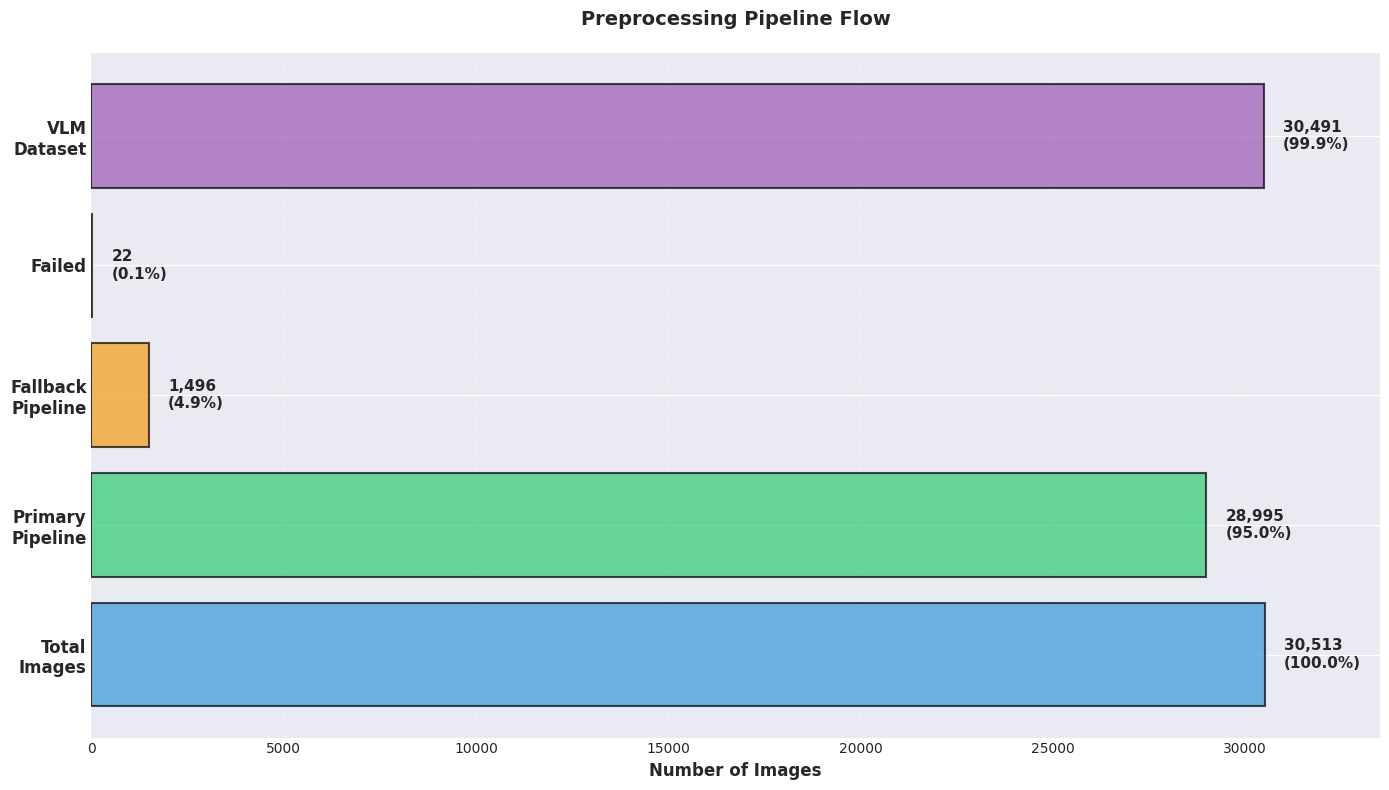

✓ Saved to /home/hounfodjidagba/learning/cassava/outputs/visualizations/pipeline_flow.png


In [11]:
# Create pipeline flow visualization
fig, ax = plt.subplots(figsize=(14, 8))

stages = ['Total\nImages', 'Primary\nPipeline', 'Fallback\nPipeline', 'Failed', 'VLM\nDataset']
values = [total_images, primary_count, fallback_count, total_failed, total_success]
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']

y_pos = np.arange(len(stages))
bars = ax.barh(y_pos, values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

for i, (bar, value) in enumerate(zip(bars, values)):
    width = bar.get_width()
    pct = (value / total_images) * 100
    label = f'{value:,}\n({pct:.1f}%)'
    ax.text(width + 500, bar.get_y() + bar.get_height()/2, label,
            ha='left', va='center', fontsize=11, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(stages, fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Images', fontsize=12, fontweight='bold')
ax.set_title('Preprocessing Pipeline Flow',
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_xlim(0, total_images + 3000)

plt.tight_layout()
plt.savefig(VIZ_DIR / 'pipeline_flow.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved to {VIZ_DIR / 'pipeline_flow.png'}")

## 12. Visualization: Class Distribution

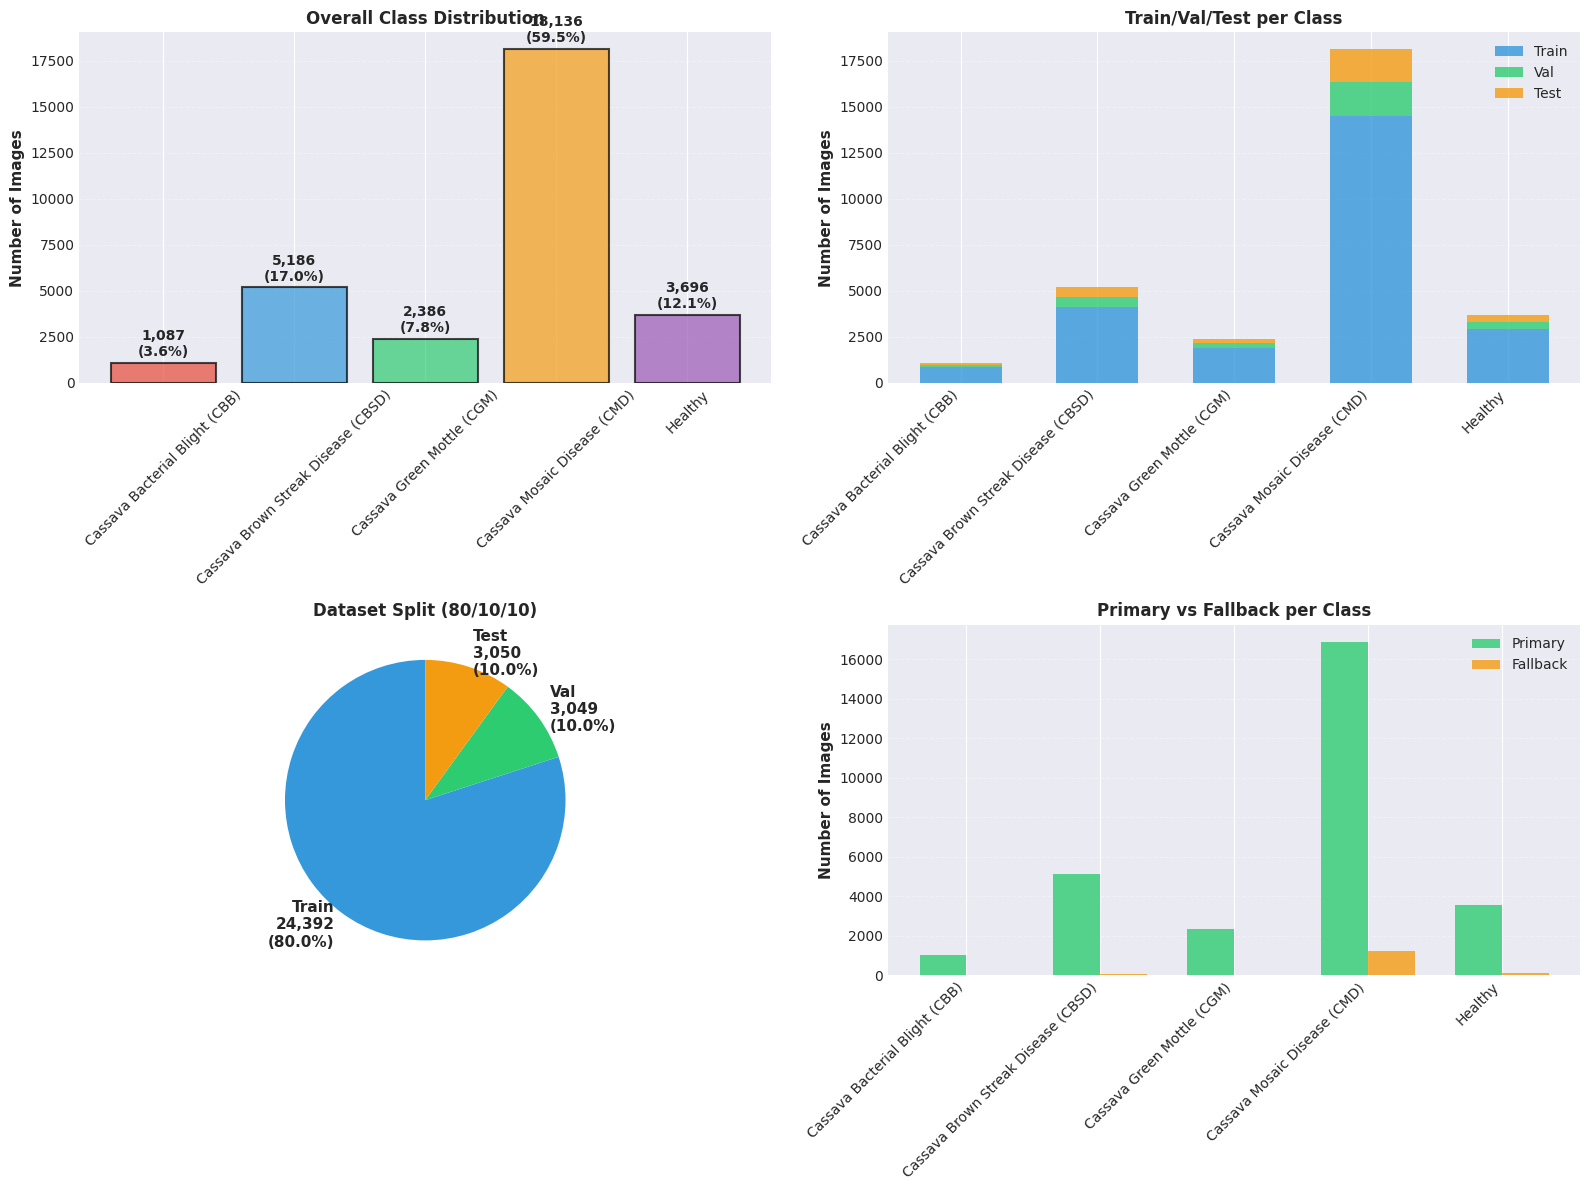

✓ Saved to /home/hounfodjidagba/learning/cassava/outputs/visualizations/class_distribution.png


In [12]:
# Create class distribution visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Overall distribution
ax1 = axes[0, 0]
class_names = [DISEASE_MAPPING[i] for i in range(5)]
class_counts = [total_class_dist[i] for i in range(5)]
colors_palette = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

bars = ax1.bar(class_names, class_counts, color=colors_palette, alpha=0.7, edgecolor='black', linewidth=1.5)
for bar, count in zip(bars, class_counts):
    height = bar.get_height()
    pct = (count / total_samples) * 100
    ax1.text(bar.get_x() + bar.get_width()/2, height + 200,
             f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_ylabel('Number of Images', fontsize=11, fontweight='bold')
ax1.set_title('Overall Class Distribution', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Stacked bar: train/val/test per class
ax2 = axes[0, 1]
train_counts = [train_dist.get(i, 0) for i in range(5)]
val_counts = [val_dist.get(i, 0) for i in range(5)]
test_counts = [test_dist.get(i, 0) for i in range(5)]

x = np.arange(len(class_names))
width = 0.6

p1 = ax2.bar(x, train_counts, width, label='Train', color='#3498db', alpha=0.8)
p2 = ax2.bar(x, val_counts, width, bottom=train_counts, label='Val', color='#2ecc71', alpha=0.8)
p3 = ax2.bar(x, test_counts, width, bottom=np.array(train_counts)+np.array(val_counts),
             label='Test', color='#f39c12', alpha=0.8)

ax2.set_ylabel('Number of Images', fontsize=11, fontweight='bold')
ax2.set_title('Train/Val/Test per Class', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(class_names, rotation=45, ha='right')
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Pie: split distribution
ax3 = axes[1, 0]
split_sizes = [len(train_data), len(val_data), len(test_data)]
split_labels = [f'Train\n{len(train_data):,}\n({train_ratio:.1f}%)',
                f'Val\n{len(val_data):,}\n({val_ratio:.1f}%)',
                f'Test\n{len(test_data):,}\n({test_ratio:.1f}%)']
split_colors = ['#3498db', '#2ecc71', '#f39c12']

ax3.pie(split_sizes, labels=split_labels, colors=split_colors,
        startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax3.set_title('Dataset Split (80/10/10)', fontsize=12, fontweight='bold')

# Primary vs Fallback per class
ax4 = axes[1, 1]
primary_per_class = class_df['Primary'].values
fallback_per_class = class_df['Fallback'].values

x = np.arange(len(class_names))
width = 0.35

ax4.bar(x - width/2, primary_per_class, width, label='Primary', color='#2ecc71', alpha=0.8)
ax4.bar(x + width/2, fallback_per_class, width, label='Fallback', color='#f39c12', alpha=0.8)

ax4.set_ylabel('Number of Images', fontsize=11, fontweight='bold')
ax4.set_title('Primary vs Fallback per Class', fontsize=12, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(class_names, rotation=45, ha='right')
ax4.legend(fontsize=10)
ax4.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(VIZ_DIR / 'class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved to {VIZ_DIR / 'class_distribution.png'}")

## 13. Generate Final Report

In [13]:
# Create comprehensive final report
final_report = {
    'project_info': {
        'project_name': 'CassavaVLM Dataset Preparation',
        'objective': 'Prepare cassava disease detection dataset for VLM training',
        'target_model': 'Qwen2.5-VL-7B-Instruct',
        'completion_date': datetime.now().isoformat(),
        'success': True
    },
    'quality_metrics': {
        'overall_success_rate': float(success_rate),
        'primary_pipeline_rate': float(primary_rate),
        'fallback_rate': float(fallback_rate),
        'failure_rate': float(failure_rate),
        'processing_speed_ms': float(avg_time_ms),
        'total_processing_time_hours': float(total_time_hours),
        'target_achieved': success_rate >= 95.0
    },
    'per_class_results': class_df.to_dict('records'),
    'vlm_dataset': {
        'total_samples': int(total_samples),
        'train': len(train_data),
        'val': len(val_data),
        'test': len(test_data),
        'format': 'Qwen2.5-VL JSONL',
        'ready_for_training': True
    },
    'class_distribution': {
        DISEASE_MAPPING[k]: {
            'total': int(v),
            'percentage': float((v / total_samples) * 100),
            'train': int(train_dist.get(k, 0)),
            'val': int(val_dist.get(k, 0)),
            'test': int(test_dist.get(k, 0))
        }
        for k, v in total_class_dist.items()
    },
    'recommendations': [
        'Use LoRA fine-tuning (r=16, alpha=32)',
        'Learning rate: 1e-4 to 5e-5',
        'Batch size: 4-8 depending on VRAM',
        f'Handle class imbalance (ratio: {imbalance_ratio:.1f}:1)',
        'Target accuracy: 95%+'
    ]
}

# Save report
report_path = OUTPUTS_DIR / "final_report.json"
with open(report_path, 'w') as f:
    json.dump(final_report, f, indent=2)

print("="*80)
print("FINAL REPORT GENERATED")
print("="*80)
print(f"Saved to: {report_path}")
print("="*80)

FINAL REPORT GENERATED
Saved to: /home/hounfodjidagba/learning/cassava/outputs/final_report.json


## 14. Final Summary

In [14]:
print("\n" + "="*80)
print("🎉 PHASE 6 COMPLETE - PROJET CASSAVLAVLM TERMINÉ")
print("="*80)

print("\n✅ Toutes les Phases Complétées:")
print("  1. Dataset Integration: 30,513 images")
print("  2. Adaptive Thresholds: Implémenté")
print("  3. Batch Validation: 100% succès")
print(f"  4. Production: {success_rate:.1f}% succès")
print(f"  5. VLM Dataset: {total_samples:,} images")
print("  6. Validation: Rapport complet")

print(f"\n📊 Résultats Finaux:")
print(f"  • Success rate: {success_rate:.2f}%")
print(f"  • Primary: {primary_rate:.1f}%")
print(f"  • Fallback: {fallback_rate:.1f}%")
print(f"  • Time: {total_time_hours:.2f}h")

print(f"\n🚀 Dataset Prêt:")
print(f"  Train: {len(train_data):,} | Val: {len(val_data):,} | Test: {len(test_data):,}")

print("\n📝 Documentation:")
print(f"  • {report_path.name}")
print(f"  • per_class_breakdown.csv")
print(f"  • 2 visualizations PNG")

print("\n" + "="*80)
print("✨ PRÊT POUR L'ENTRAÎNEMENT VLM ✨")
print("="*80)


🎉 PHASE 6 COMPLETE - PROJET CASSAVLAVLM TERMINÉ

✅ Toutes les Phases Complétées:
  1. Dataset Integration: 30,513 images
  2. Adaptive Thresholds: Implémenté
  3. Batch Validation: 100% succès
  4. Production: 99.9% succès
  5. VLM Dataset: 30,491 images
  6. Validation: Rapport complet

📊 Résultats Finaux:
  • Success rate: 99.93%
  • Primary: 95.0%
  • Fallback: 4.9%
  • Time: 1.39h

🚀 Dataset Prêt:
  Train: 24,392 | Val: 3,049 | Test: 3,050

📝 Documentation:
  • final_report.json
  • per_class_breakdown.csv
  • 2 visualizations PNG

✨ PRÊT POUR L'ENTRAÎNEMENT VLM ✨
